# Esercitazione 10

**5 Maggio 2026**

*Gradiente e Gradiente Coniugato*

## Esercizio 1
Implementare la funzione **steepestdescent(A,b,x0,itmax,tol)** che implementa il metodo di discesa più ripida del gradiente per risolvere il sistema lineare Ax=b, con A matrice simmetrica e definita positiva. La funzione prende in input:
- A: matrice dei coefficienti
- b: termine noto
- x0: vettore iniziale della stessa dimensione di b
- itmax: iterazioni massime oltre le quali il metodo si ferma
- toll: tolleranza per il criterio di arresto

e restituisce in output:
- il vettore soluzione
- un vettore di tante componenti quanto il numero di iterazioni effettuate, contenente $ \frac{||r^{(k)}||_2} {||b||_2}$ iterazione per iterazione

- un array contenente le soluzioni ad ogni iterazione
- il numero di iterazioni impiegate per calcolare la soluzione con la tolleranza richiesta

Usare come criterio di arresto $ \frac{||r^{(k)}||_2} {||b||_2} < toll$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def steepestdescent(A,b,x0,itmax,tol):

    x = x0
    r = A@x - b
    p = -r #direzione di discesa opposta al gradiente (Gradientee di F = r = Ax-b)
    it = 0
    nb = np.linalg.norm(b)
    errore = np.linalg.norm(r) / nb

    vec_sol = []
    vec_sol.append(x0)
    vet_r = []
    vet_r.append(errore)
    
    while errore >= tol and it < itmax:
        it = it + 1
        Ap = A@p
        #Calcolo del passo ottimo (Minimizzo lungo la direzione p)
        alpha = -(r.T@p) / (p.T@Ap)

        x = x + alpha * p

        vec_sol.append(x)
        
        #Aggiorno il residuo

        r = r + alpha * Ap
        errore = np.linalg.norm(r) / nb
        vet_r.append(errore)

        #Definisco la nuova direzionoe per l'iterazione successiva
        p=-r
        
    iterates_array = np.array(vec_sol).squeeze()

    #output
    return x, vet_r, iterates_array, it

[[-2.]
 [ 6.]]
Numero Iterazioni  83


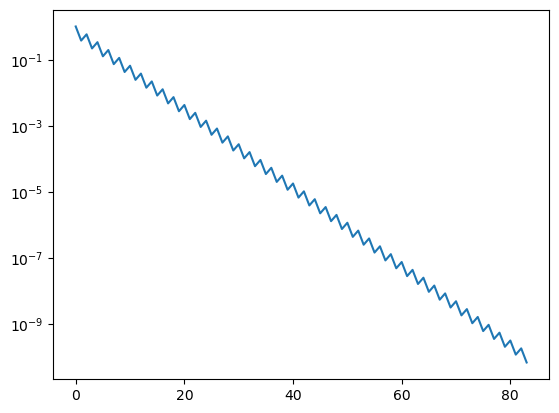

In [3]:
A=np.array([[8,4],[4,3]])
b=np.array([8,10]).reshape(2, 1)
x0 = np.zeros_like(b)
itmax = 200
tol = 1e-10

xG_1, vet_rG_1, iterates_array_1, it_G1 = steepestdescent(A,b,x0,itmax,tol)

plt.semilogy(range(it_G1 + 1), vet_rG_1)
print(xG_1)
print("Numero Iterazioni ", it_G1)

## Esercizio 1-Bis
Implementare la funzione **steepestdescent_CL(A,b,x0,itmax,X,Y,Z,f,tol)** da utilizzare solo nel caso n=2 che visualizza anche le curve di livello e l'iterato x_k.

N.B: f(x) è il funzionale quadratico da minimizzare (f(x)= <Ax,x>-<b,x>) ,
X,Y sono la discretizzazione del piano su cui costruire Z (ottenuta valutando f sui punti della griglia)

In [4]:
def conjugate_gradient(A,b,x0,itmax,tol):

    x = x0
    r = A@x - b
    p = -r #direzione di discesa opposta al gradiente (Gradientee di F = r = Ax-b)
    it = 0
    nb = np.linalg.norm(b)
    errore = np.linalg.norm(r) / nb

    vec_sol = []
    vec_sol.append(x0)
    vet_r = []
    vet_r.append(errore)
    
    while errore >= tol and it < itmax:
        it = it + 1
        Ap = A@p
        #Calcolo del passo ottimo (Minimizzo lungo la direzione p)
        alpha = -(r.T@p) / (p.T@Ap)

        x = x + alpha * p

        vec_sol.append(x)

        rtr_old = r.T@r
        
        #Aggiorno il residuo

        r = r + alpha * Ap

        gamma = (r.T@r) / rtr_old
        
        errore = np.linalg.norm(r) / nb
        vet_r.append(errore)

        #Definisco la nuova direzionoe per l'iterazione successiva
        p = -r + gamma * p
        
    iterates_array = np.array(vec_sol).squeeze()

    #output
    return x, vet_r, iterates_array, it

[[-2.]
 [ 6.]]
Numero Iterazioni  2


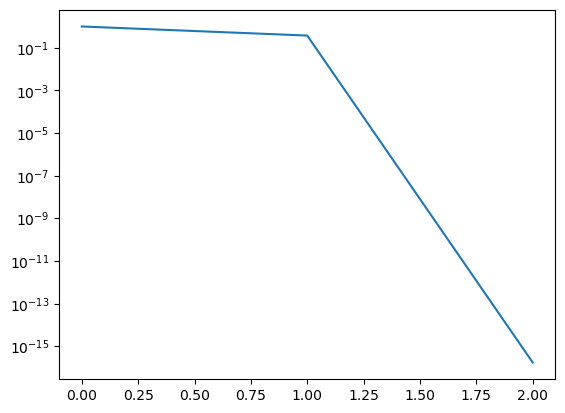

In [5]:
xCG_1, vet_rCG_1, iterates_array_1, it_GC1 = conjugate_gradient(A,b,x0,itmax,tol)
plt.semilogy(range(it_GC1 + 1), vet_rCG_1)
print(xCG_1)
print("Numero Iterazioni ", it_GC1)

## Test didattici per il caso n=2, visualizzando le curve di livello

Risolvere il sistema lineare Ax=b, dove A=np.array([[8,4],[4,3]]) e b=np.array([8,10]), utilizzando
il metodo del gradiente con la visualizzazione grafica delle curve di livello e della soluzione ad ogni iterazione. Si selezioni l'iterato iniziale x0=[0,0], itmax=200
tol=1e-10. Si visualizzi l'errore ad ogni iterazione. La soluzione esatta del sistema è il vettore x=[-2,6])

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Funzione obiettivo (forma quadratica)
   
 

# Parametri
A=np.array([[8,4],[4,3]]) 
print("--------",np.linalg.det(A))
b=np.array([[8.0],[10.0]])          
x0 = np.array([[0.0], [0.0]])      # Punto iniziale

toll = 1e-10
itmax = 500

# Esecuzione
x=np.linspace(-7.0,3,100)
y=np.linspace(-5,14,100)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        x = np.array([[X[i, j]], [Y[i, j]]])
        Z[i, j] = f(x, A, b)
        
x_G, vet_er, iterates, it = steepestdescent_CL(A,b,x0,itmax,X,Y,Z,f,toll)

# Stampa dei risultati
print("Soluzione sistema ", x_G)
print("Numero di iterati ", it)
# Visualizzazione grafica 3D
# Creazione della griglia per la superficie
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot della superficie

surf = ax.plot_surface(X, Y, Z, cmap='Blues', alpha=0.6, rstride=1, cstride=1, linewidth=0)

# Calcolo di z_iterates
z_iterates = np.array([f(iterates[i, :].reshape(2, 1), A, b) for i in range(iterates.shape[0])])
print("*****",iterates.shape, z_iterates.shape)
# Plot del percorso degli iterati
ax.plot(iterates[:, 0], iterates[:, 1], z_iterates.flatten(), color='red', linewidth=2, label='Percorso a zig-zag')
ax.scatter(iterates[:5, 0], iterates[:5, 1], z_iterates[:5].flatten(), color='red', s=80, label='Iterati')

# Punto iniziale e minimo

ax.scatter([x0[0, 0]], [x0[1, 0]], [f(x0, A, b)], color='blue', s=200, marker='o', label='Punto iniziale')
ax.scatter([x_G[0, 0]], [x_G[1, 0]], f(x_G,A,b), color='green', s=200, marker='*', label='Minimo trovato')

# Personalizzazione
ax.set_title(f'Metodo del Gradiente per f(x) = 0.5*x^T A x - b^T x')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
ax.legend()
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='f(x, y)')
plt.show()
print("cond A",np.linalg.norm(A))

## Esercizio 2
Implementare la funzione **conjugate_gradient(A,b,x0,itmax,tol)** che implementa il metodo del gradiente coniugato per risolvere il sistema lineare Ax=b, con A matrice simmetrica e definita positiva. La funzione prende in input:
- A: matrice dei coefficienti
- b: termine noto
- x0: vettore iniziale della stessa dimensione di b
- itmax: iterazioni massime oltre le quali il metodo si ferma
- toll: tolleranza per il criterio di arresto

e restituisce in output:
- il vettore soluzione
- un vettore di tante componenti quanto il numero di iterazioni effettuate, contenente $ \frac{||r^{(k)}||_2} {||b||_2}$ iterazione per iterazione
- un array contenente le soluzioni ad ogni iterazione
- il numero di iterazioni impiegate per calcolare la soluzione con la tolleranza richiesta

Usare come criterio di arresto $ \frac{||r^{(k)}||_2} {||b||_2} < toll$

## Esercizio 2-Bis
Implementare la funzione **conjugate_gradient_CL(A,b,x0,itmax,X,Y,Z,f,tol)** da utilizzare solo nel caso n=2 che visualizza anche le curve di livello e l'iterato x_k

x0=np.zeros_like(b)
itmax=200
tol=1e-10
x_cg_0,vet_r_cg_0,iterates_cg,itcg_0=conjugate_gradient_CL(A,b,x0,itmax,X,Y,Z,f,tol)
print(itcg_0)

# Visualizzazione grafica 3D
# Creazione della griglia per la superficie
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot della superficie

surf = ax.plot_surface(X, Y, Z, cmap='Blues', alpha=0.6, rstride=1, cstride=1, linewidth=0)

# Calcolo di z_iterates
z_iterates = np.array([f(iterates_cg[i, :].reshape(2, 1), A, b) for i in range(iterates_cg.shape[0])])

# Plot del percorso degli iterati
ax.plot(iterates_cg[:, 0], iterates_cg[:, 1], z_iterates.flatten(), color='red', linewidth=2, label='Percorso a zig-zag')
ax.scatter(iterates_cg[:1, 0], iterates_cg[:1, 1], iterates_cg[:1].flatten(), color='red', s=80, label='Iterati')

# Punto iniziale e minimo

ax.scatter([x0[0, 0]], [x0[1, 0]], [f(x0, A, b)], color='blue', s=200, marker='o', label='Punto iniziale')
ax.scatter([x_cg_0[0, 0]], [x_cg_0[1, 0]], f(x_cg_0,A,b), color='green', s=200, marker='*', label='Minimo trovato')

# Personalizzazione
ax.set_title(f'Metodo del Gradiente Coniugato per f(x) = 0.5*x^T A x - b^T x')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
ax.legend()
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='f(x, y)')
plt.show()
 

## Esercizio 3
Scrivere una funzione creaPoisson(n) che preso in input l'ordine della matrice quadrata di Poisson la costruzione secondo la seguente formula:
$$A =
\left [
\begin{array}{ccccccccccc}
4 & -1 & 0 & -1 &0 &0 & 0& 0& \cdots &   0 & 0\\
-1 & 4 & -1 & 0  &-1 &0 & 0& 0& \cdots &   0 & 0\\
0 & -1 & 4 & -1  &0 &-1 & 0& 0& \cdots &   0 & 0 \\
-1 & 0 & -1 & 4  &-1 &0  & -1 & 0& \cdots &   0 & 0\\
0 & -1 & 0 & -1  & 4 &-1 & 0 & -1& \cdots &   0 & 0\\
0 & 0 & -1 & 0  & -1 &4 & -1 & 0&  -1 & 0 & 0 \\
0 & 0 & 0 & \ddots  & 0 &\ddots & \ddots & \ddots& \ddots & \ddots & 0\\
0 & 0 & 0 & 0  & -1 &0  & -1 & 4& -1 &   0& -1\\
\end{array}
 \right ], \qquad
$$

- Risolvere il sistema lineare Ax=b con matrice dei coefficienti A di Poisson con ordine che va da 10 a 100 con step 2,  e termine noto b scelto in maniera tale che il sistema abbia soluzione il vettore x con tutte le componenti  uguali ad 1, utilizzando  il metodo iterativo del gradiente e del gradiente coniugato  

In [6]:
def creaPoisson(n):
    #costruire una matrice di Poisson
    d=np.ones((n))*4
    e=-np.ones((n-1,))
    f=-np.ones((n-3,))
    A=np.diag(d)+np.diag(e,-1)+np.diag(e,1)+np.diag(f,-3)+np.diag(f,3)
    return A

## Esercizio 4
Consideriamo il sistema lineare Ax=b  dov A è  la matrice di Hilbert di dimensione 5, costruita usando la funzione hilbert(n) di scipy.linalg (A=scipy.linalg.hilbert(5)) in modo tale che la soluzione esatta sia $x = (1, 1, . . . , 1)^T$ .
Risolvere il sistema lineare usando sia il metodo del gradiente che ilmetodo del gradiente coniugato e  visualizzare gli errori ad ogni iterazione.

In [7]:
from scipy.linalg import hilbert

n4 = 5
A4 = hilbert(n4)
b4 = np.sum(A4, axis=1).reshape(n4, 1)
x04 = np.zeros_like(b4)
itmax = 10000
toll = 1e-10
condA = np.linalg.cond(A4)
print("Condizionamento di Hilbert ", condA)

Condizionamento di Hilbert  476607.25024172297


[[1.00000984]
 [1.00017879]
 [0.99825543]
 [1.0036409 ]
 [0.9978593 ]]
Numero Iterazioni  10000
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]]
Numero Iterazioni  7


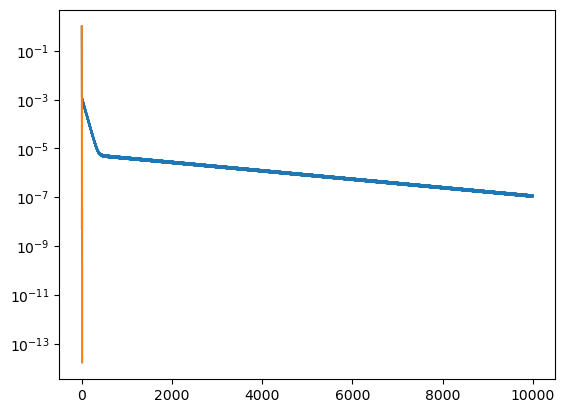

In [8]:
xG_4, vet_rG_4, iterates_array_4, it_G4 = steepestdescent(A4,b4,x04,itmax,tol)

plt.semilogy(range(it_G4 + 1), vet_rG_4)
print(xG_4)
print("Numero Iterazioni ", it_G4)

xCG_4, vet_rCG_4, iterates_array_4, it_GC4 = conjugate_gradient(A4,b4,x04,itmax,tol)
plt.semilogy(range(it_GC4 + 1), vet_rCG_4)
print(xCG_4)
print("Numero Iterazioni ", it_GC4)

## Esercizio 5
Importare il file creaG ed utilizzare le funzioni sottospecificate per creare, scelto $n$,  una matrice D di ordine $m=(n-2)^2$

*import creaG*

*G = creaG.numgrid(n)*

*D = creaG.delsq(G).todense().getA()*

Risolvere il sistema lineare Dx=b, con matrice G di ordine m=16 ed ordine m=400, (scegliere n in maniera opportuna), usando il metodo del gradiente. Visualizzare graficamente l'errore ad ogni iterazione.

### Codice EquazioniNormali
Implementare la function  **eqnorm(A,b)** che implementa il metodo delle equazioni normali per la soluzione del sistema sovradeterminato Ax=b e che prende in input:
- la matrice A di dimensione $m \times n$ , $m>n$
- il termine noto b di ordine m
restituisce in output
- la soluzione del sistema lineare 

In [9]:
from scipy.linalg import cholesky
from SolveTriangular import *

In [10]:
def eqnorm(A, b):
    G = A.T@A
    f = A.T@b

    L = cholesky(G, lower=True)
    LT = L.T

    z, flag = Lsolve(L, f)
    if flag == 0:
        x, flag = Usolve(LT, z)

    return x

### Codice QRLS
Implementare la function  **qrLS(A,b)** che utilizza il metodo QR per la soluzione del sistema sovradeterminato Ax=b e che prende in input:
- la matrice A di dimensione $m \times n$ , $m>n$
- il termine noto b di ordine m
restituisce in output
- la soluzione del sistema lineare e la norma 2 al quadrato del residuo.

### Codice SVDLS
Implementare la function  **svdLS(A,b)** che utilizza  il metodo SVD per la soluzione del sistema sovradeterminato Ax=b e che prende in input:
- la matrice A di dimensione $m \times n$ , $m>n$
- il termine noto b di ordine m
restituisce in output
- la soluzione del sistema lineare e la norma 2 al quadrato del residuo.

## Esercizio 6
- Si utilizzino i tre metodi implementati  per l'approssimazione ai minimi quadrati delle seguenti configurazioni di dati:

$$
\begin{array}{l}
x_1 = [-3.5, \, -3, \, -2, \, -1.5, \, -0.5, \, 0.5, \, 1.7, \, 2.5, \, 3] ;\\
y_1 = [-3.9, \, -4.8, \, -3.3, \, -2.5, \, 0.3, \, 1.8, \, 4, \, 6.9, \, 7.1] ;\\
x_2 = [-3.14, \, -2.4, \, -1.57, \, -0.7, \, -0.3, \, 0, \, 0.4, \, 0.7, \, 1.57] ;\\
y_2 = [0.02, \, -1, \, -0.9, \, -0.72, \, -0.2, \, -0.04, \, 0.65, \, 0.67, \, 1.1] ;\\
x_3 = [[1.001,\, 1.004,\, 1.005,\,1.0012, \,1.0013,  \, 1.0014,  \, 1.0015, \, 1.0016] ;\\
y_3 = [-1.2, \, -0.95, \, -0.9, \, -1.15, \, -1.1, \, -1] ;\\
\end{array}
$$

al variare del grado $n$ tra 1 e 4.

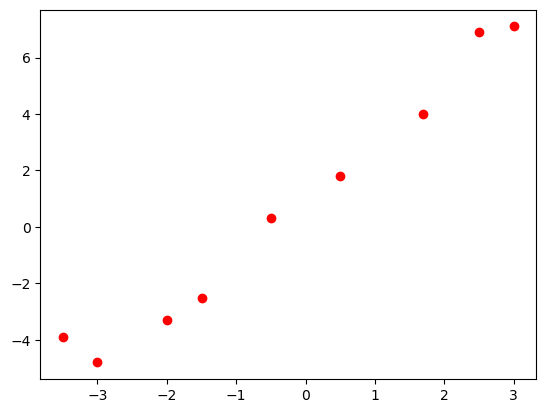

In [11]:
x_1 = np.array([-3.5, -3, -2, -1.5, -0.5, 0.5, 1.7, 2.5, 3])
y_1 = np.array([-3.9, -4.8, -3.3, -2.5, 0.3, 1.8, 4, 6.9, 7.1])
plt.plot(x_1, y_1, 'ro')

(9, 2)
[[1.21492318]
 [1.90511021]]


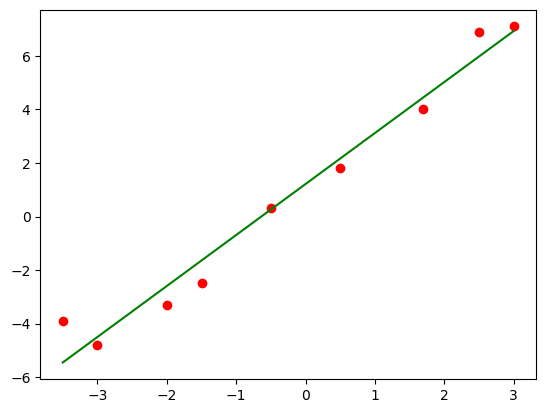

In [13]:
m = x_1.shape[0]
n = 1
n1 = n + 1
B = np.vander(x_1, increasing=True)[:,:n1]
print(B.shape)
alpha_EQN = eqnorm(B, y_1)
print(alpha_EQN)
xv = np.linspace(np.min(x_1), np.max(x_1))
pol_EQN = np.polyval(np.flip(alpha_EQN), xv)
plt.plot(x_1, y_1, 'ro', xv, pol_EQN, 'g-')

## Esercizio 7: 
Per i dati $(x_i, y_i)$ riportati nei seguenti array

$$
\begin{array}{l}
x = [0.0004, \, 0.2507, \, 0.5008, \, 2.0007, \, 8.0013]  ;\\
y = [0.0007, \, 0.0162, \, 0.0288, \, 0.0309, \, 0.0310] ;
\end{array}
$$

- costruire la retta di regressione;
- costruire la parabola approssimante i dati nel senso dei minimi quadrati;

Quale tra le due approssimazioni risulta la migliore? (Confrontare i grafici e la norma euclidea al quadrato del vettore dei residui).


##  Esercizio 8 – Approssimazione di immagini tramite SVD

Si consideri un’immagine digitale rappresentata come una matrice (o come tre matrici nel caso RGB).
Implementare un metodo di **compressione dell’immagine** basato sulla **decomposizione ai valori singolari (SVD)**, ottenendo un’approssimazione di rango ridotto.


È possibile utilizzare immagini già disponibili senza scaricare file esterni.
img = plt.imread(plt.cbook.get_sample_data('grace_hopper.jpg'))


1. Scrivere una funzione che:

   * prenda in input un’immagine e un intero ( r )
   * restituisca un’approssimazione dell’immagine di **rango ( r )** utilizzando la SVD

2. Applicare la funzione a un’immagine e:

   * visualizzare l’immagine originale e quella approssimata
   * confrontare qualitativamente i risultati al variare di ( r )

3. Calcolare il **PSNR (Peak Signal-to-Noise Ratio)** tra immagine originale e approssimata

4. Studiare come varia la qualità:

   * rappresentare il **PSNR in funzione di ( r )**

---
